# Integration of DE and HE multiome datasets

In [81]:
here::i_am("rna/mapping/run/mnn/mapping_mnn.R")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

# Load packages
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(org.Mm.eg.db))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(batchelor))

opts$genotype.color = c('WT'= 'black','Eomes_KO'= 'red')


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code



In [6]:
io$homedir = '/rds/project/rds-SDzz0CATGms/users/bt392'
args = list()
args$sce_DE = file.path(io$homedir, '10_Eomes_invitro_gut/processed/rna/SingleCellExperiment.rds')
args$meta_DE = file.path(io$homedir, '10_Eomes_invitro_gut/results/rna/mapping/sample_metadata_after_mapping.txt.gz')

args$sce_HE = file.path(io$homedir, '09_Eomes_invitro_blood/processed/rna/SingleCellExperiment.rds')
args$meta_HE = file.path(io$homedir, '09_Eomes_invitro_blood/results/rna/mapping/sample_metadata_after_mapping.txt.gz')

In [12]:
sce_DE = readRDS(args$sce_DE)
meta_DE = fread(args$meta_DE) %>%
    .[pass_rnaQC==TRUE & doublet_call == FALSE] %>% 
    .[,dataset:='DE']
sce_DE = sce_DE[,meta_DE$cell]

sce_HE = readRDS(args$sce_HE)
meta_HE = fread(args$meta_HE) %>%
    .[pass_rnaQC==TRUE & doublet_call == FALSE] %>% 
    .[,dataset:='HE']
sce_HE = sce_HE[,meta_HE$cell]

In [14]:
head(meta_HE)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,pass_rnaQC,doublet_score,doublet_call,celltype,celltype.score,closest.cell,day_celltype,celltype_genotype,dataset
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,6110,22923,6.09,10.15,day3_wt_rep1,D3,wt,TRUE,1.15,FALSE,Epiblast,0.84,cell_85485,D3-wt,Epiblast-wt,HE
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,4201,10794,6.57,7.38,day3_wt_rep1,D3,wt,TRUE,0.53,FALSE,Primitive_Streak,0.56,cell_88836,D3-wt,Primitive_Streak-wt,HE
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,3659,8745,5.74,11.92,day3_wt_rep1,D3,wt,TRUE,0.31,FALSE,Epiblast,0.88,cell_1799,D3-wt,Epiblast-wt,HE
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,3640,8461,3.70,7.21,day3_wt_rep1,D3,wt,TRUE,0.16,FALSE,Primitive_Streak,0.72,cell_43612,D3-wt,Primitive_Streak-wt,HE
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,AAACATGCAATCCTGA-1,1A_Eo_DEG_G9_day3,3632,8276,4.60,8.16,day3_wt_rep1,D3,wt,TRUE,0.21,FALSE,Epiblast,0.52,cell_106685,D3-wt,Epiblast-wt,HE
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,AAACATGCACTTAGGC-1,1A_Eo_DEG_G9_day3,4878,15676,7.34,8.97,day3_wt_rep1,D3,wt,TRUE,0.64,FALSE,Primitive_Streak,0.40,cell_28316,D3-wt,Primitive_Streak-wt,HE


In [15]:
meta_HE$genotype = ifelse(meta_HE$genotype == 'wt', 'WT', 'Eomes_KO')

In [9]:
sce_DE
sce_HE

class: SingleCellExperiment 
dim: 32285 59525 
metadata(0):
assays(1): counts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(59525): RBG43471#AAACAGCCAACACTTG-1
  RBG43471#AAACAGCCACATACTG-1 ... RBG43478#TTTGTTGGTTAGGTTG-1
  RBG43478#TTTGTTGGTTGGTTGA-1
colData names(11): barcode sample ... pass_rnaQC sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [87]:
str(sce_DE)

Formal class 'SingleCellExperiment' [package "SingleCellExperiment"] with 9 slots
  ..@ int_elementMetadata:Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  .. .. ..@ rownames       : NULL
  .. .. ..@ nrows          : int 32285
  .. .. ..@ listData       :List of 1
  .. .. .. ..$ rowPairs:Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  .. .. .. .. .. ..@ rownames       : NULL
  .. .. .. .. .. ..@ nrows          : int 32285
  .. .. .. .. .. ..@ listData       : Named list()
  .. .. .. .. .. ..@ elementType    : chr "ANY"
  .. .. .. .. .. ..@ elementMetadata: NULL
  .. .. .. .. .. ..@ metadata       : list()
  .. .. ..@ elementType    : chr "ANY"
  .. .. ..@ elementMetadata: NULL
  .. .. ..@ metadata       : list()
  ..@ int_colData        :Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  .. .. ..@ rownames       : NULL
  .. .. ..@ nrows          : int 55111
  .. .. ..@ listData       :List of 3
  .. .. .. ..$ reducedDims:Formal class 'DFrame' [package "S4V

# Start writing function

In [83]:
integrate_datasets = function(genotype_i=c('WT'),
                                day_i=c('D3'),
                                features=2500,
                                batch_variable='dataset',
                                npcs=25,
                                n_neighbors=30,
                                min_dist=0.3){

    # Subset HE
    meta_HE_tmp = meta_HE[genotype %in% genotype_i & day %in% day_i]
    sce_HE_tmp = sce_HE[, meta_HE_tmp$cell]
    colData(sce_HE_tmp) = meta_HE_tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
                          .[colnames(sce_HE_tmp),] %>% DataFrame()
        
    # Subset DE
    meta_DE_tmp = meta_DE[genotype %in% genotype_i & day %in% day_i]
    sce_DE_tmp = sce_DE[, meta_DE_tmp$cell]
    colData(sce_DE_tmp) = meta_DE_tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
                          .[colnames(sce_DE_tmp),] %>% DataFrame()
    
    # Merge SCE objects
    sce = cbind(sce_HE_tmp, sce_DE_tmp)
    meta = rbind(meta_HE_tmp, meta_DE_tmp)
    
    # normalisation
    sce <- logNormCounts(sce)
    decomp <- modelGeneVar(sce)
    decomp <- decomp[decomp$mean > 0.01,]
    hvgs <- decomp[order(decomp$FDR),] %>% head(n=features) %>% rownames

    # Subset SCE to highly variable genes
    sce_filt <- sce[hvgs,]

    # PCA and batch correction
    pca.mtx <- multiBatchPCA(sce_filt, batch = colData(sce_filt)[[batch_variable]], d = npcs, preserve.single=FALSE)
    pca.corrected <- reducedMNN(pca.mtx)$corrected 
    reducedDim(sce_filt, "PCA") <- pca.corrected[colnames(sce),]

    # Run UMAP
    sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = n_neighbors, min_dist = min_dist)
    umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
      .[,cell:=colnames(sce_filt)] %>%
      setnames(c("UMAP1","UMAP2","cell")) %>%
        merge(meta, by='cell')

    # plots
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=dataset)) + 
        geom_point(size = 0.5) + 
        ggtitle('dataset') + 
        theme_void()

    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('Celltype') + 
        theme_void() + 
        theme(legend.position='none')

    p3 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=day)) + 
        geom_point() + 
        scale_colour_manual(values=opts$days.colors) + 
        ggtitle('stage') + 
        theme_void()

    p4 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=genotype)) + 
        geom_point(size=0.5) + 
        scale_colour_manual(values=opts$genotype.color) + 
        ggtitle('genotype') + 
        theme_void()

    p5 =  ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('dataset') +
        facet_grid(~dataset) + 
        theme_void() + 
        theme(legend.position='none', 
             text=element_text(size=20))

    p6 =  ggplot(umap.dt, aes(UMAP1, UMAP2, col=genotype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$genotype.color) + 
        ggtitle('genotype') +
        facet_grid(~genotype) + 
        theme_void() + 
        theme(legend.position='none', 
             text=element_text(size=20))

    options(repr.plot.width=20, repr.plot.height=10) 
    plots = ggarrange(ggarrange(p1, p2, p3, p4, ncol=4), 
              ggarrange(p5,p6, ncol=2),
                ncol=1)

    return(plots)
}

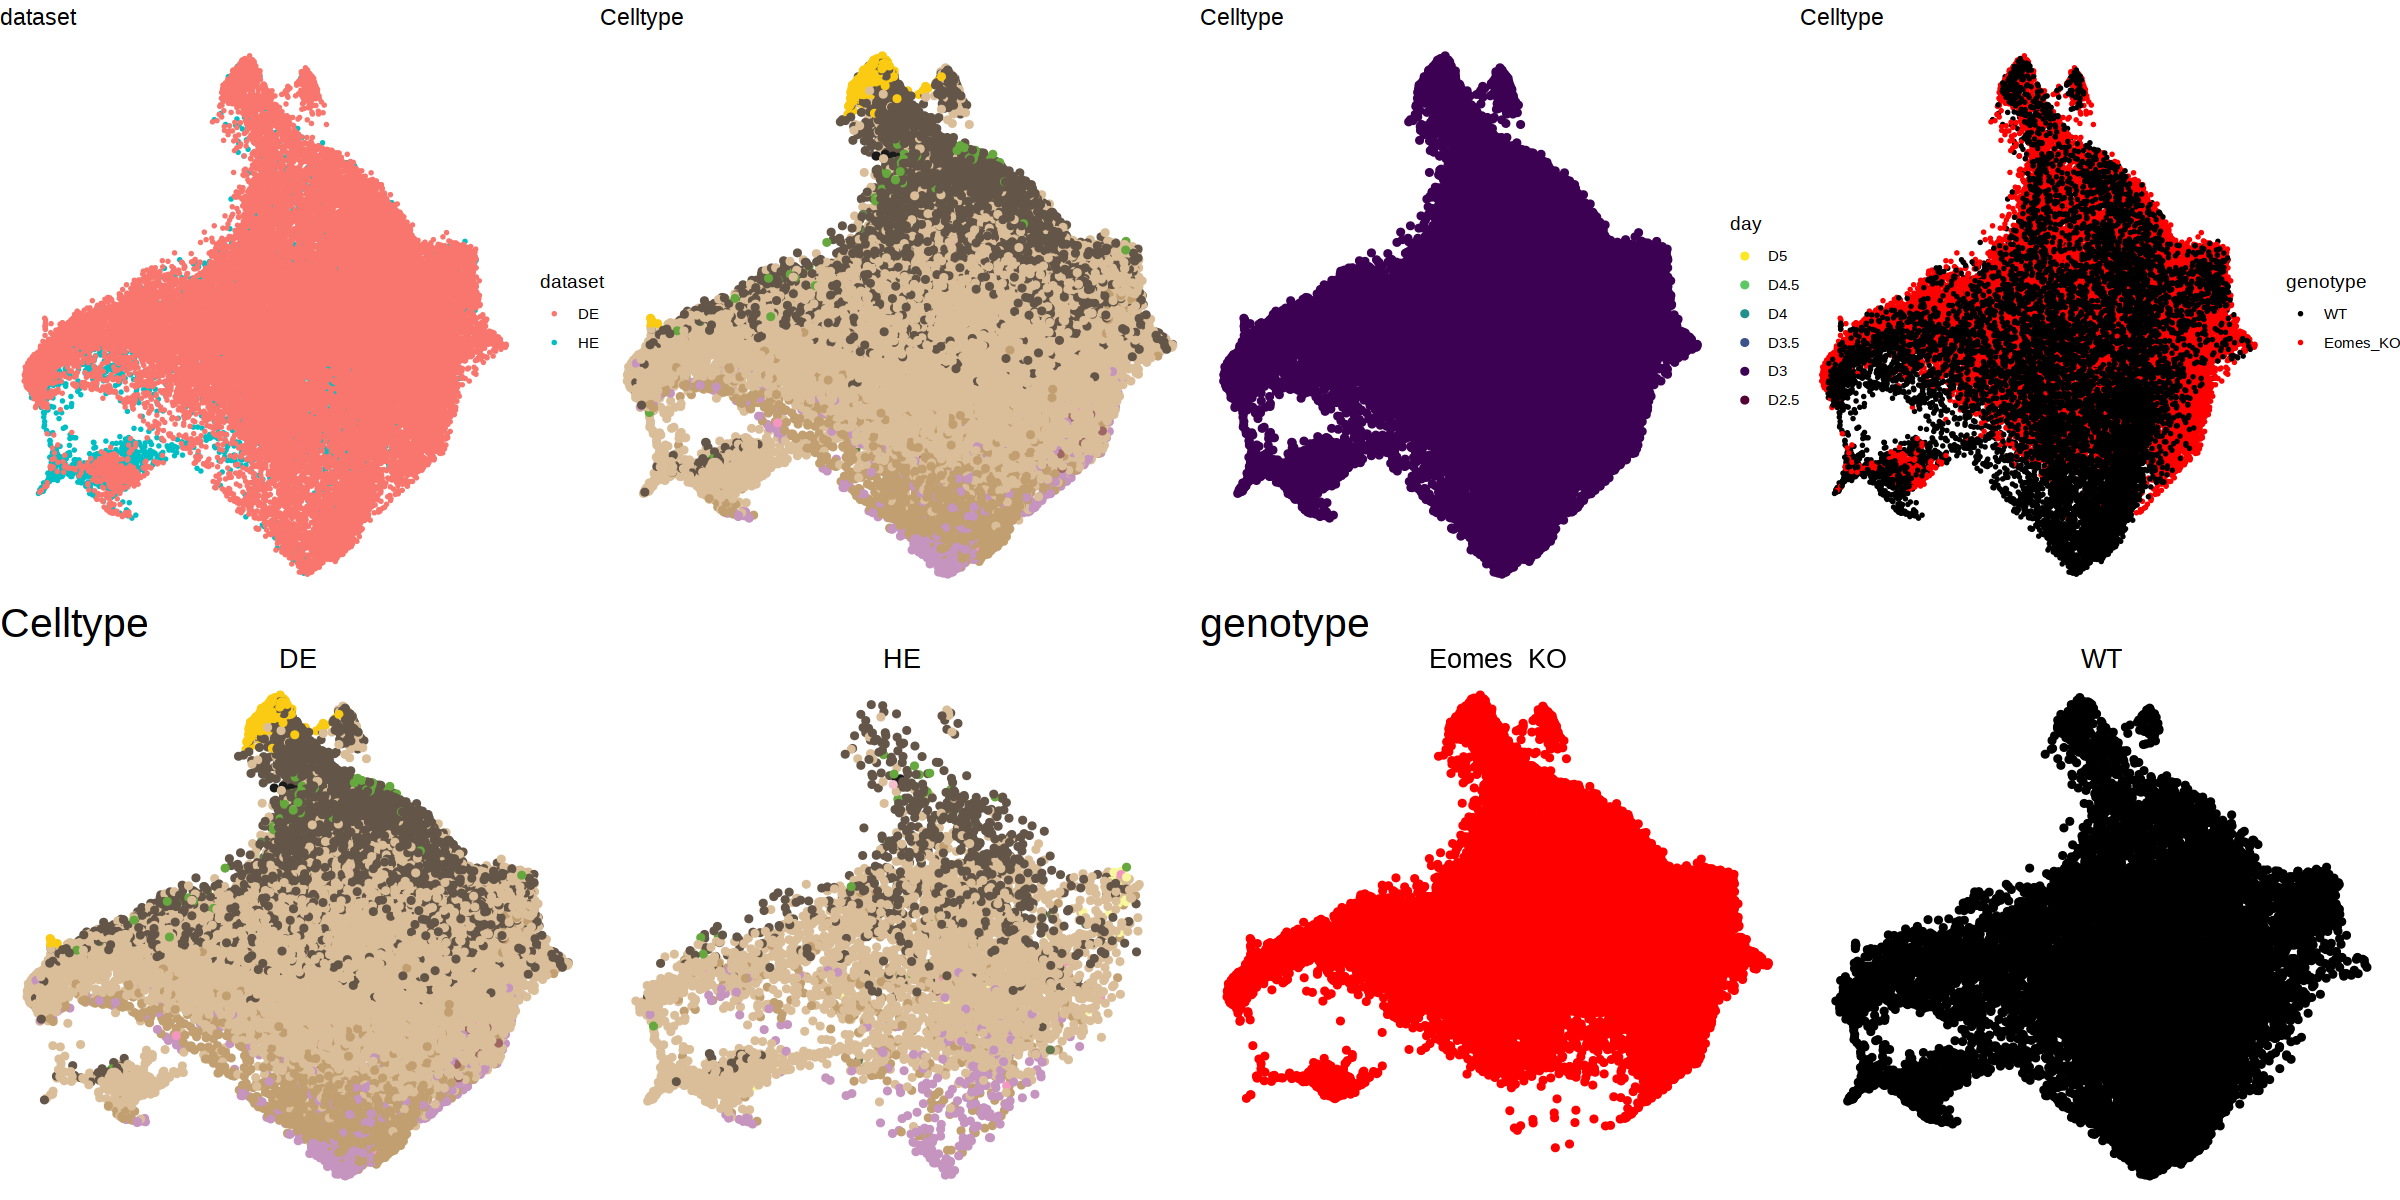

In [84]:
integrate_datasets(genotype_i = c('WT', 'Eomes_KO'))

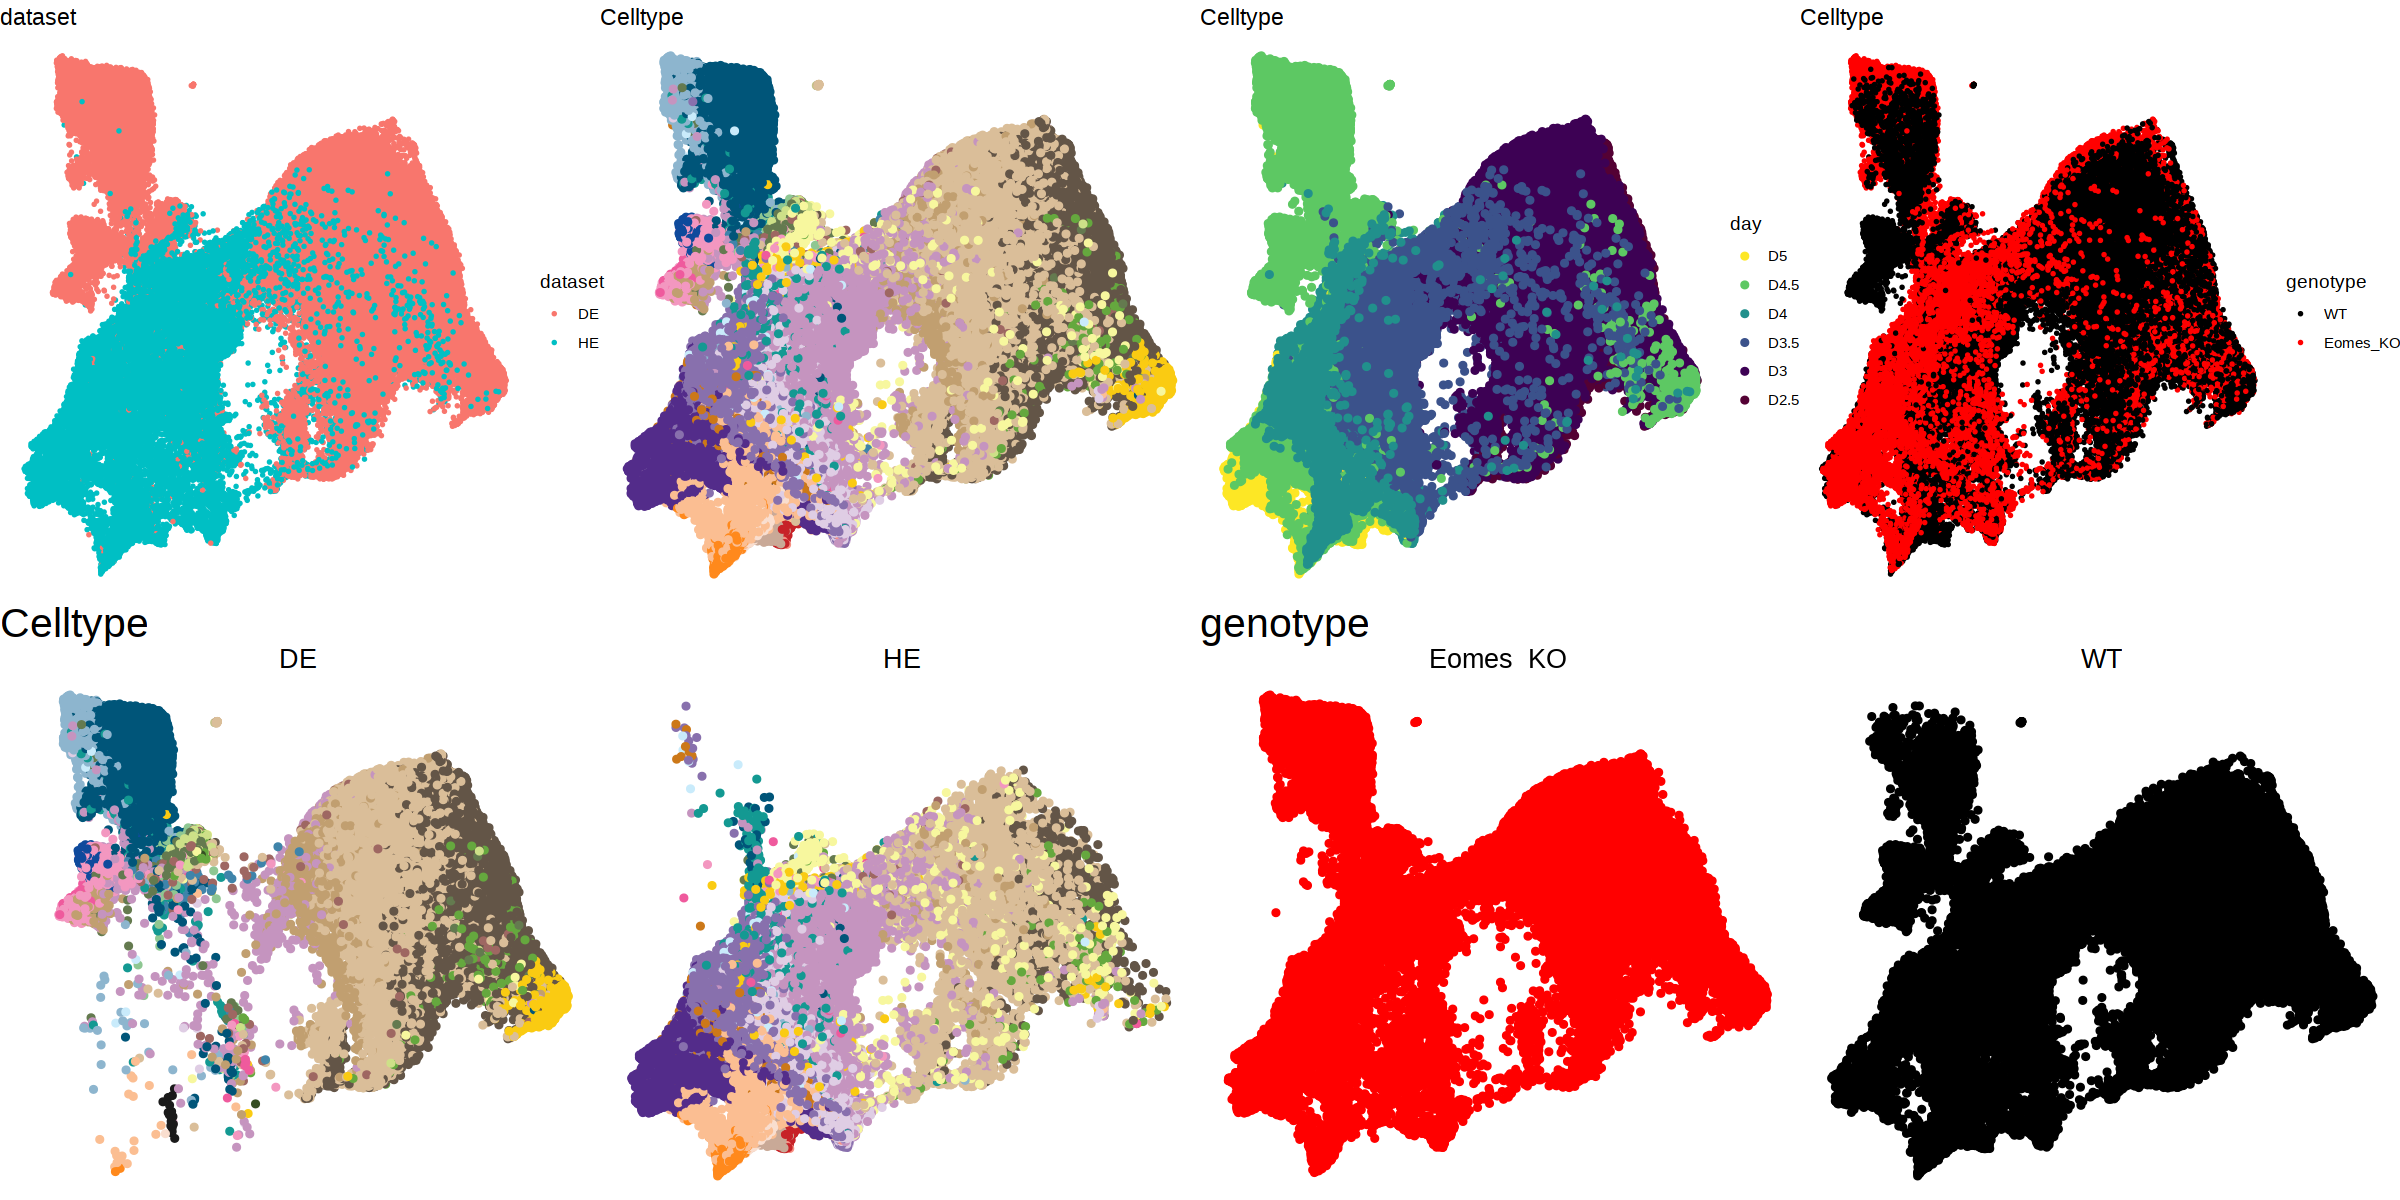

In [85]:
integrate_datasets(genotype_i = c('WT', 'Eomes_KO'),
                  day_i = c('D2.5', 'D3', 'D3.5', 'D4', 'D4.5', 'D5'))

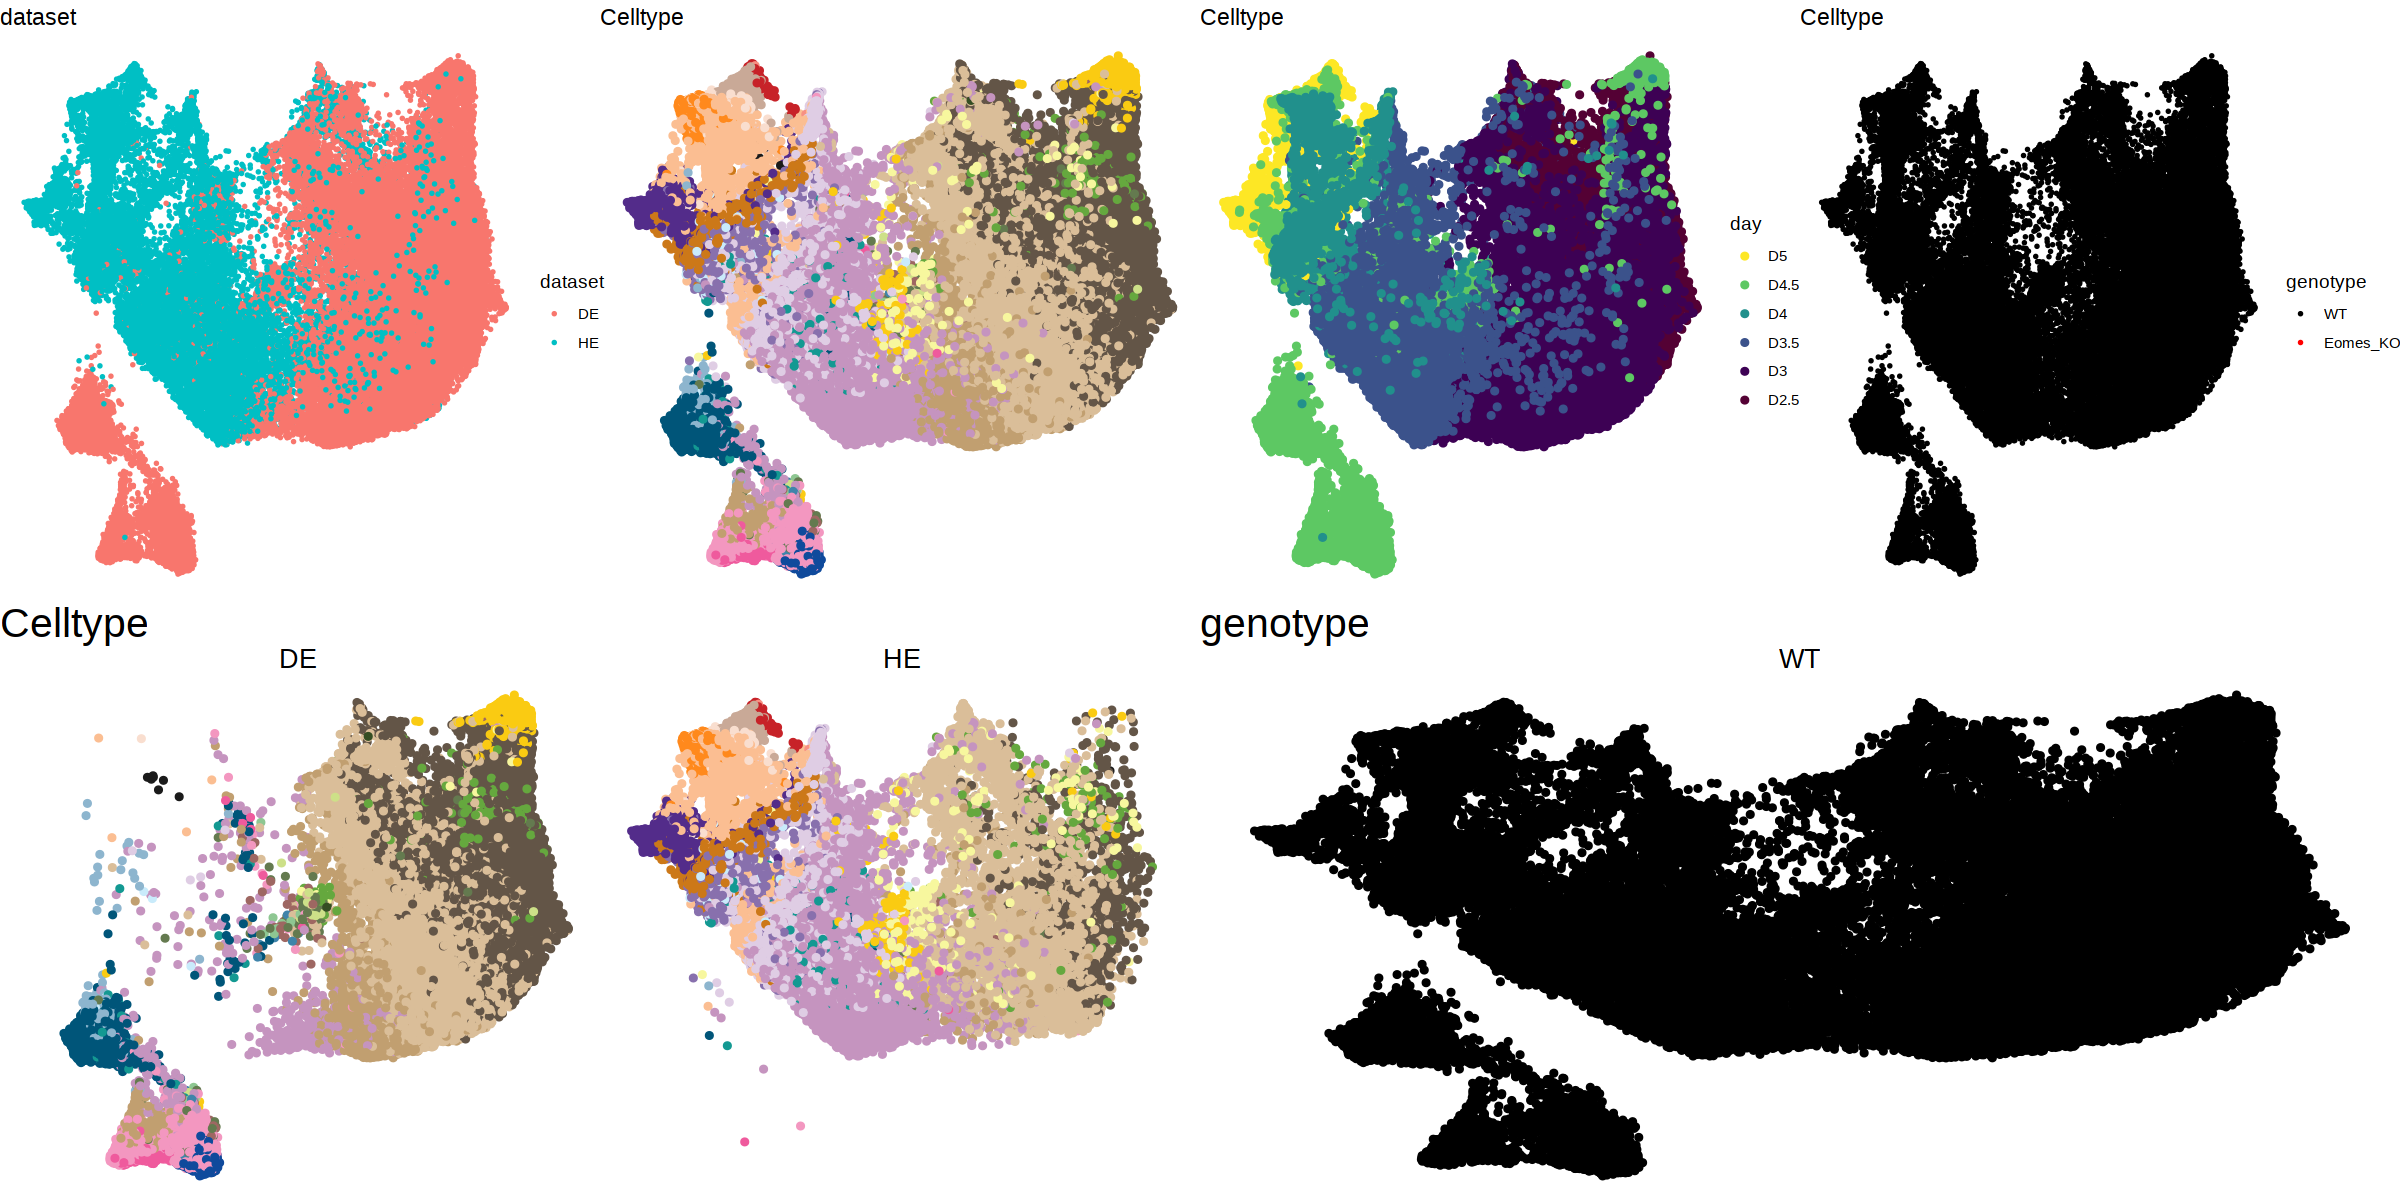

In [86]:
integrate_datasets(genotype_i = c('WT'),
                  day_i = c('D2.5', 'D3', 'D3.5', 'D4', 'D4.5', 'D5'))

In [103]:
genotype_i=c('WT')
day_i=c('D3')
features=2500
batch_variable='dataset'
npcs=25
n_neighbors=30
min_dist=0.3

In [104]:
    # Subset HE
    meta_HE_tmp = meta_HE[genotype %in% genotype_i & day %in% day_i]
    sce_HE_tmp = sce_HE[, meta_HE_tmp$cell]
    colData(sce_HE_tmp) = meta_HE_tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
                          .[colnames(sce_HE_tmp),] %>% DataFrame()
        
    # Subset DE
    meta_DE_tmp = meta_DE[genotype %in% genotype_i & day %in% day_i]
    sce_DE_tmp = sce_DE[, meta_DE_tmp$cell]
    colData(sce_DE_tmp) = meta_DE_tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
                          .[colnames(sce_DE_tmp),] %>% DataFrame()
    
    # Merge SCE objects
    sce = cbind(sce_HE_tmp, sce_DE_tmp)
    meta = rbind(meta_HE_tmp, meta_DE_tmp)
    
    # normalisation
    sce <- logNormCounts(sce)
    decomp <- modelGeneVar(sce)
    decomp <- decomp[decomp$mean > 0.01,]
    hvgs <- decomp[order(decomp$FDR),] %>% head(n=features) %>% rownames

    # Subset SCE to highly variable genes
    sce_filt <- sce[hvgs,]

    # PCA and batch correction
    pca.mtx <- multiBatchPCA(sce_filt, batch = colData(sce_filt)[[batch_variable]], d = npcs, preserve.single=TRUE)

In [154]:
sce_filt = runPCA(sce_filt, ncomponents = 25, scale=TRUE, ntop=features)

In [155]:
PCA = reducedDim(sce_filt,"PCA")

In [156]:
pcs = as.data.table(PCA, keep.rownames=T) %>%
    setnames(c('cell', paste0('PC', 1:25))) %>%
    merge(meta, by='cell')

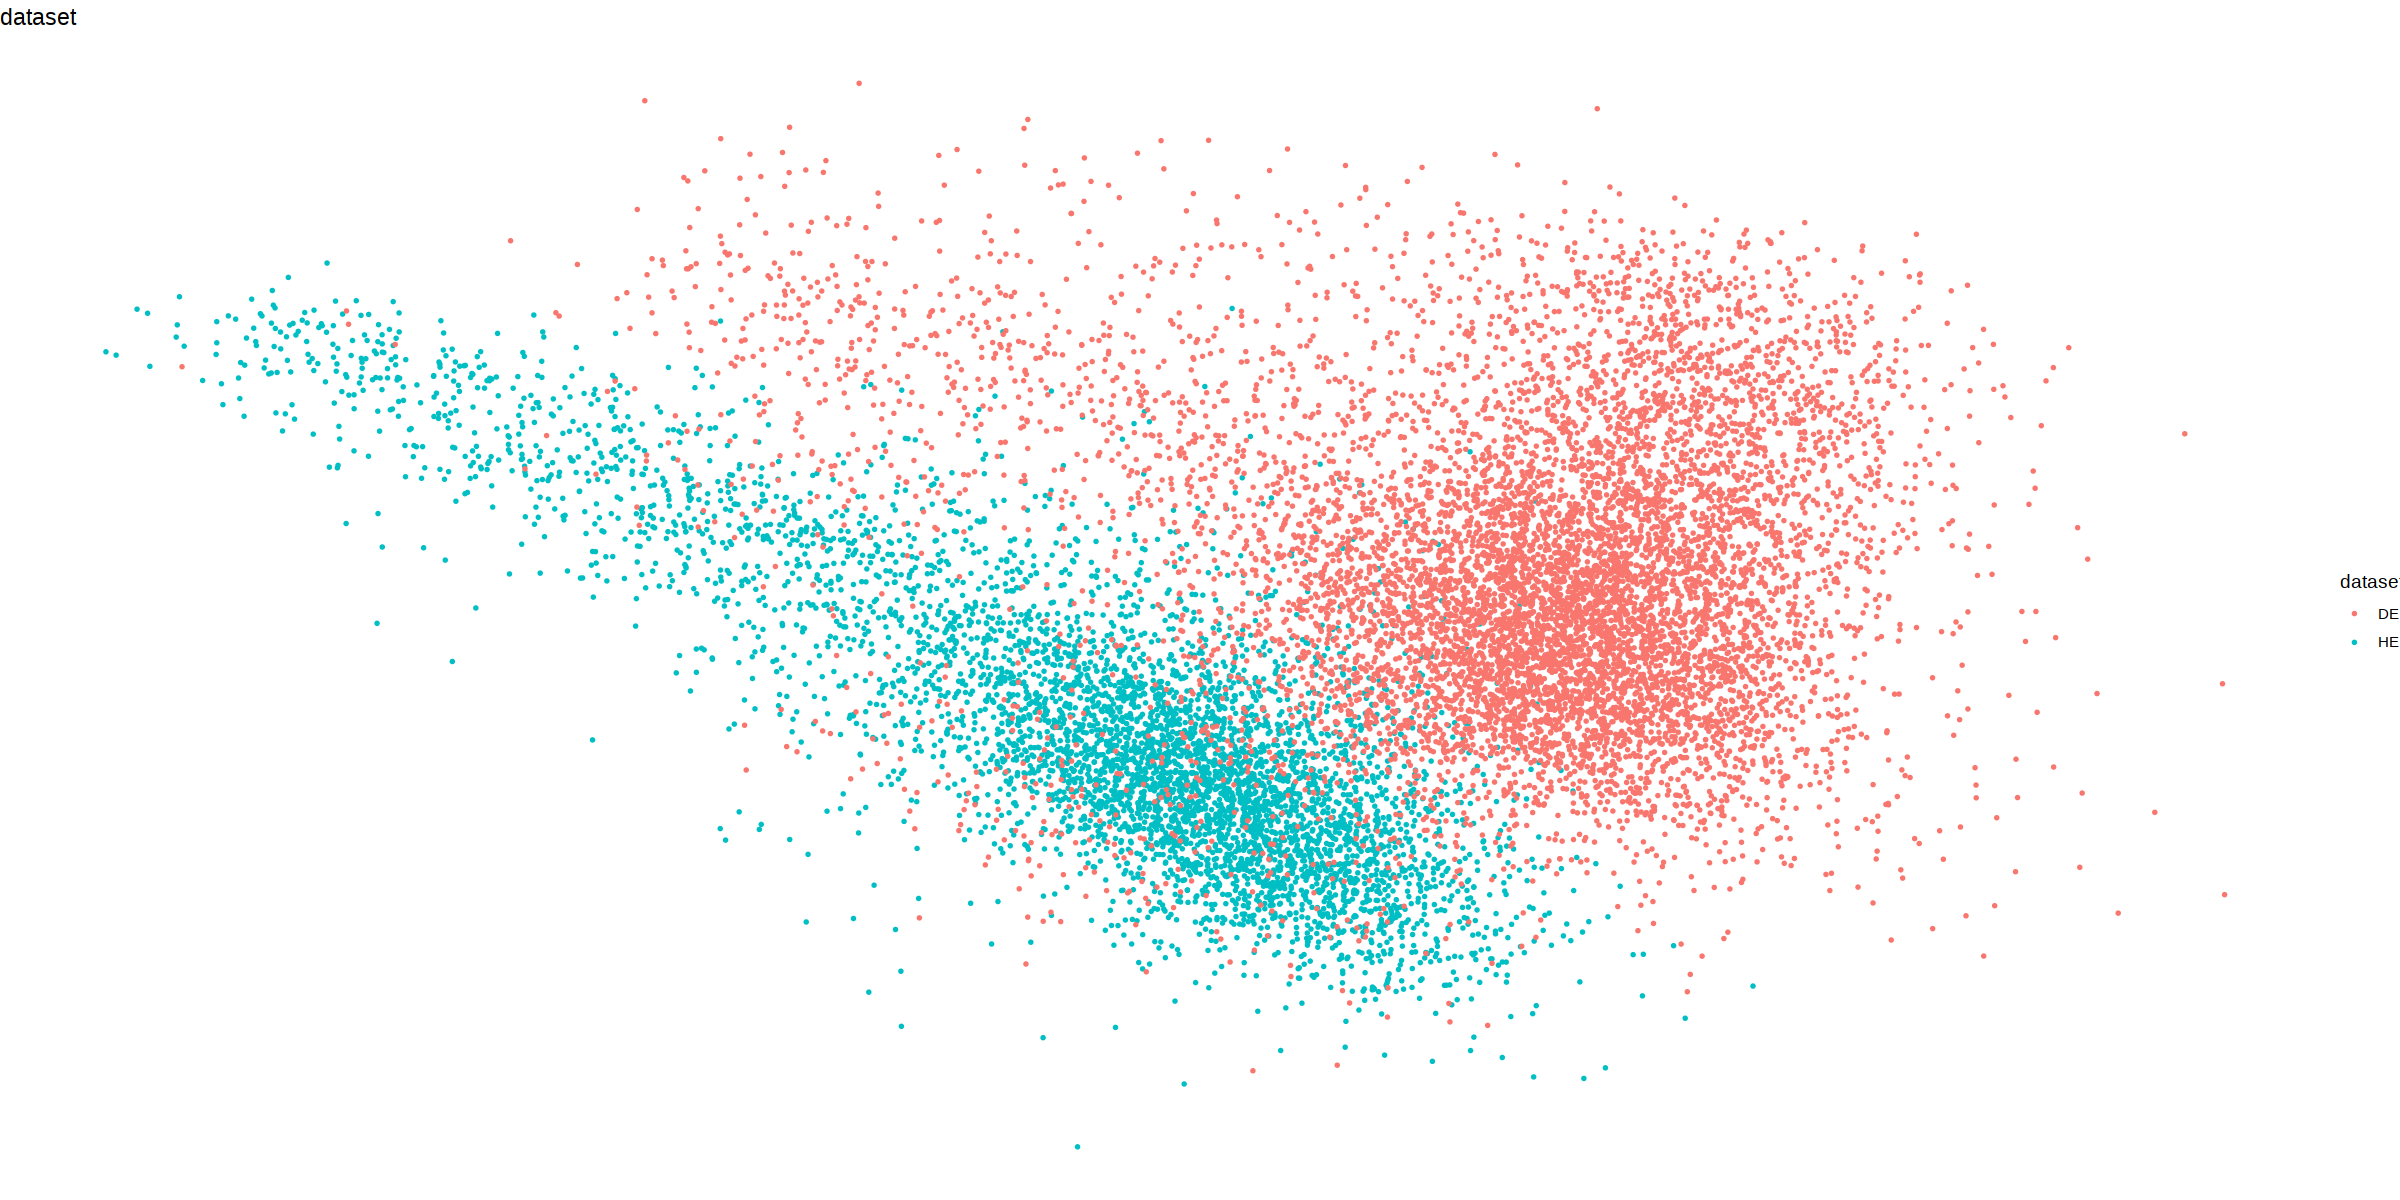

In [157]:
ggplot(pcs, aes(PC1, PC2, col=dataset)) +       
        geom_point(size = 0.5) + 
        ggtitle('dataset') + 
        theme_void()

In [158]:
PCA = reducedDim(sce_filt,"PCA")

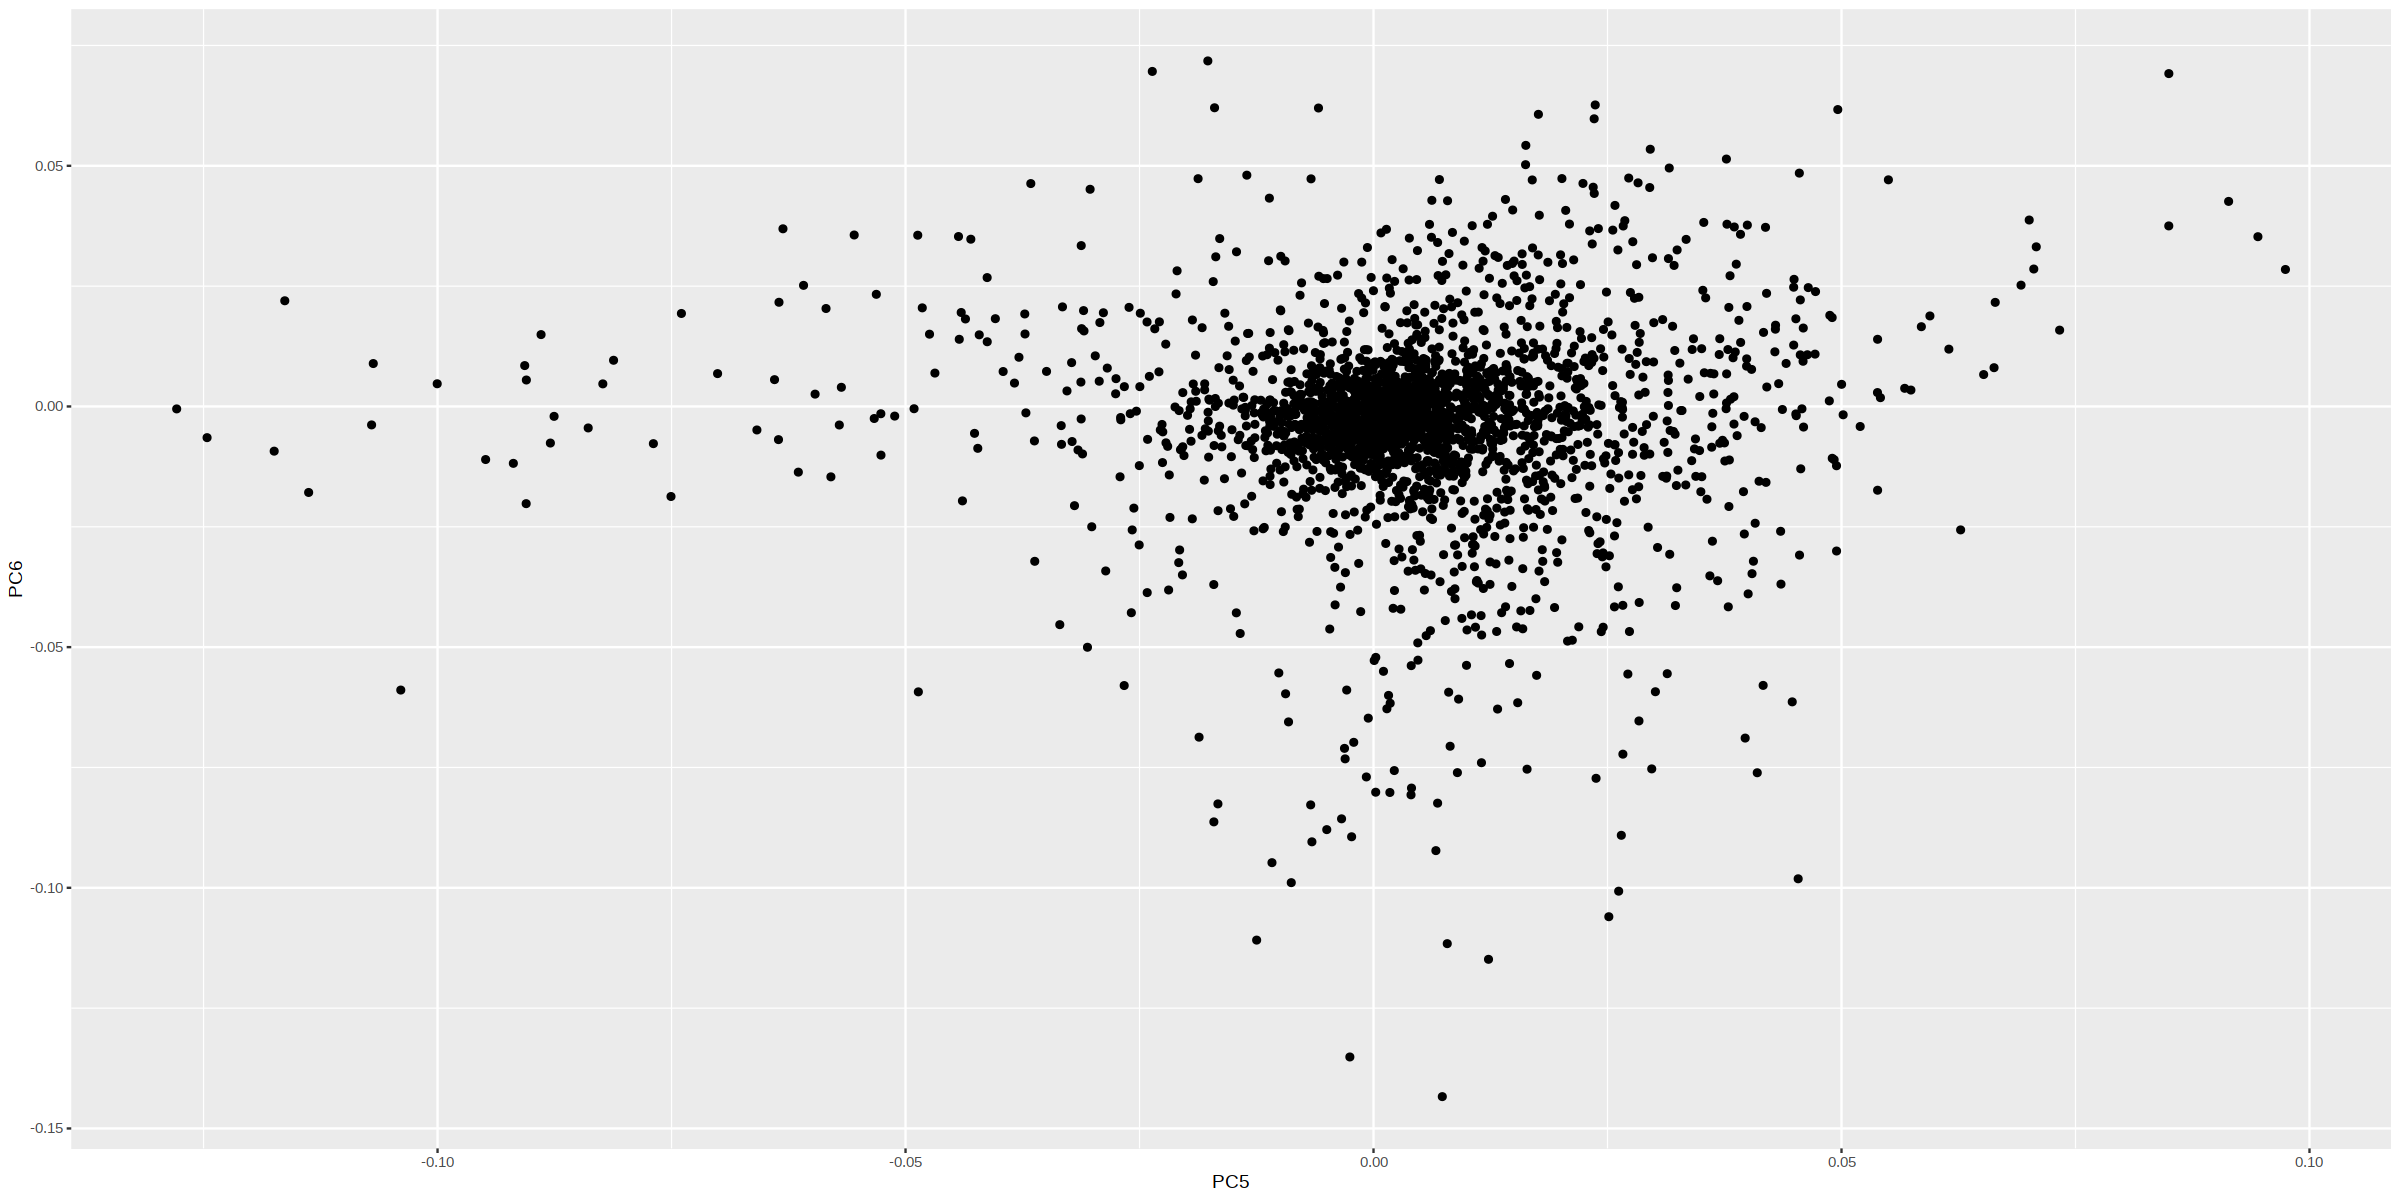

In [167]:
ggplot(as.data.frame(attributes(PCA)$rotation), aes(PC5, PC6)) + geom_point()

In [172]:
as.data.table(attributes(PCA)$rotation, keep.rownames=T)[order(PC5)]

rn,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,⋯,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Cenpf,0.0010919383,-0.032152810,0.035029323,-0.034248861,-0.12786997,-0.0005055891,0.0300370385,0.080594495,-0.055003990,⋯,0.0297527781,-0.005035870,0.0215614258,0.0248368073,0.027307253,-0.045393356,0.0435567397,0.005010144,2.556665e-02,-0.0195517759
Prc1,0.0261023872,-0.032840776,0.016192181,-0.034572505,-0.12462347,-0.0064770437,0.0148954247,0.049797848,-0.056825935,⋯,-0.0076914700,0.026881817,0.0298464299,0.0436163647,0.036200445,-0.062033527,0.0077085248,0.024457599,-1.641829e-02,0.0203159353
Cenpe,0.0269056527,-0.007115372,0.008521515,-0.025104181,-0.11745339,-0.0092848074,0.0359767660,0.090160487,-0.042802770,⋯,0.0324534645,0.006963158,0.0223862167,0.0434389397,0.049589175,-0.056670893,0.0222854486,0.043401306,-6.336558e-03,-0.0013411867
Top2a,0.0014769513,-0.041837873,0.043781729,-0.048664941,-0.11632055,0.0219608007,-0.0206305027,-0.021550077,-0.038091600,⋯,0.0104295769,0.037858204,0.0511972741,0.0573553628,0.023179259,-0.073639553,0.0799334740,0.058035636,-1.079884e-03,-0.0223408437
Hmmr,0.0225772358,-0.013160264,0.006394575,-0.030021111,-0.11377109,-0.0178643094,0.0302376836,0.086747310,-0.041993252,⋯,0.0116903747,0.026160359,0.0287387514,0.0533045485,0.045947801,-0.054780863,0.0177381329,0.049269653,-1.562136e-02,0.0099127256
Tpx2,0.0128543435,-0.025704918,0.022887487,-0.035647468,-0.10704616,-0.0038315590,0.0098388590,0.060739041,-0.027166275,⋯,0.0212338783,0.028340620,0.0389230874,0.0399884515,0.005489674,-0.039643763,0.0171073824,0.037001313,-1.764988e-02,-0.0116440278
Mis18bp1,0.0235003476,-0.044359657,0.021781678,-0.039810335,-0.10686725,0.0089184919,0.0032999618,0.044975088,-0.021742459,⋯,0.0201582723,0.042715170,0.0488353469,0.0297986762,0.001390394,-0.051241406,0.0164668903,0.048097483,-4.102358e-02,0.0218254133
Malat1,0.0419485556,-0.079981266,0.013753641,-0.033777510,-0.10392719,-0.0589180223,-0.0140943660,0.006569575,-0.033765549,⋯,-0.0162734061,-0.030929023,-0.0187317748,-0.0210826873,-0.003035152,0.004579852,0.0117420912,-0.023106203,3.878907e-02,0.0028502536
Kif18a,0.0263313747,-0.040808168,0.009516840,-0.028239119,-0.10003645,0.0047169611,0.0067238162,0.042950575,-0.032218773,⋯,0.0220922022,0.031098555,0.0679238927,0.0158668786,0.011050010,-0.042330997,0.0085103246,0.045167055,-2.437145e-02,0.0135269536


In [159]:
sce_filt@int_colData@listData$reducedDims@listData$PCA@

ERROR: Error in parse(text = x, srcfile = src): <text>:2:0: unexpected end of input
1: sce_filt@int_colData@listData$reducedDims@listData$PCA@
   ^


In [160]:
str(sce_filt)

Formal class 'SingleCellExperiment' [package "SingleCellExperiment"] with 9 slots
  ..@ int_elementMetadata:Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  .. .. ..@ rownames       : NULL
  .. .. ..@ nrows          : int 2500
  .. .. ..@ listData       :List of 1
  .. .. .. ..$ rowPairs:Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  .. .. .. .. .. ..@ rownames       : NULL
  .. .. .. .. .. ..@ nrows          : int 2500
  .. .. .. .. .. ..@ listData       : Named list()
  .. .. .. .. .. ..@ elementType    : chr "ANY"
  .. .. .. .. .. ..@ elementMetadata: NULL
  .. .. .. .. .. ..@ metadata       : list()
  .. .. ..@ elementType    : chr "ANY"
  .. .. ..@ elementMetadata: NULL
  .. .. ..@ metadata       : list()
  ..@ int_colData        :Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  .. .. ..@ rownames       : NULL
  .. .. ..@ nrows          : int 14484
  .. .. ..@ listData       :List of 3
  .. .. .. ..$ reducedDims:Formal class 'DFrame' [package "S4Vec

In [175]:
args = commandArgs(trailingOnly=TRUE)
kk = as.numeric(args[1])
time_1 = time_point[kk]

Warning message in eval(expr, envir, enclos):
“NAs introduced by coercion”


In [178]:
args


[1] "/home/bt392/.local/share/jupyter/runtime/kernel-4c4f732f-fb08-4963-8b88-f4a4f541ba05.json"